In [ ]:
%load_ext autoreload
%autoreload 2


In [8]:
%reload_ext autoreload
import csv
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# remove RankWarning
import warnings
warnings.simplefilter('ignore', np.RankWarning)

In [ ]:
# define plotting function for loss, loss_h, loss_c, l2 pose loss, yaw error in one plot
def plot_metric(df, title):
    
    metric = ["loss", "loss_h", "loss_c", "trans_l2_m", "yaw_err_deg"]
    fig, ax = plt.subplots(2, 3, figsize=(12, 6))
    
    for m in metric:
        last_mean = df[m][-500:].mean()
        sns.scatterplot(data=df, x=df.index, y=m, label="Final Mean: {:.4f}".format(last_mean), s=1, ax=ax.flatten()[metric.index(m)])
        # trend line
        z = np.polyfit(df.index, df[m],15)
        p = np.poly1d(z)
        ax.flatten()[metric.index(m)].plot(df.index, p(df.index), "r--", label='Trend Line')
        ax.flatten()[metric.index(m)].set_xlabel('Iterations')
        ax.flatten()[metric.index(m)].set_ylim([0, df[m].max()*1.1])
        ax.flatten()[metric.index(m)].set_ylabel(m)
        ax.flatten()[metric.index(m)].set_title(m+' over Training Iterations')
        ax.flatten()[metric.index(m)].legend()
        ax.flatten()[metric.index(m)].grid()
    fig.suptitle(title)
    fig.tight_layout()
    fig.show()

# Latest training

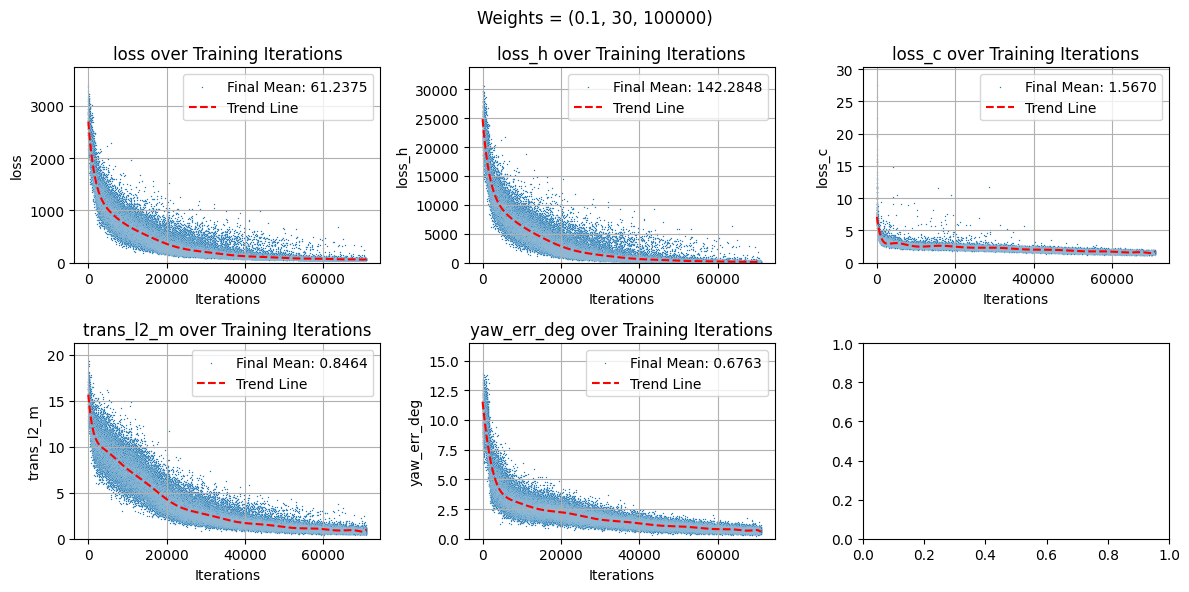

In [14]:
df = pd.read_csv("metrics/train/2026_01_09_14_37_09.csv")
plot_metric(df, "Weights = (0.1, 30, 100000)")

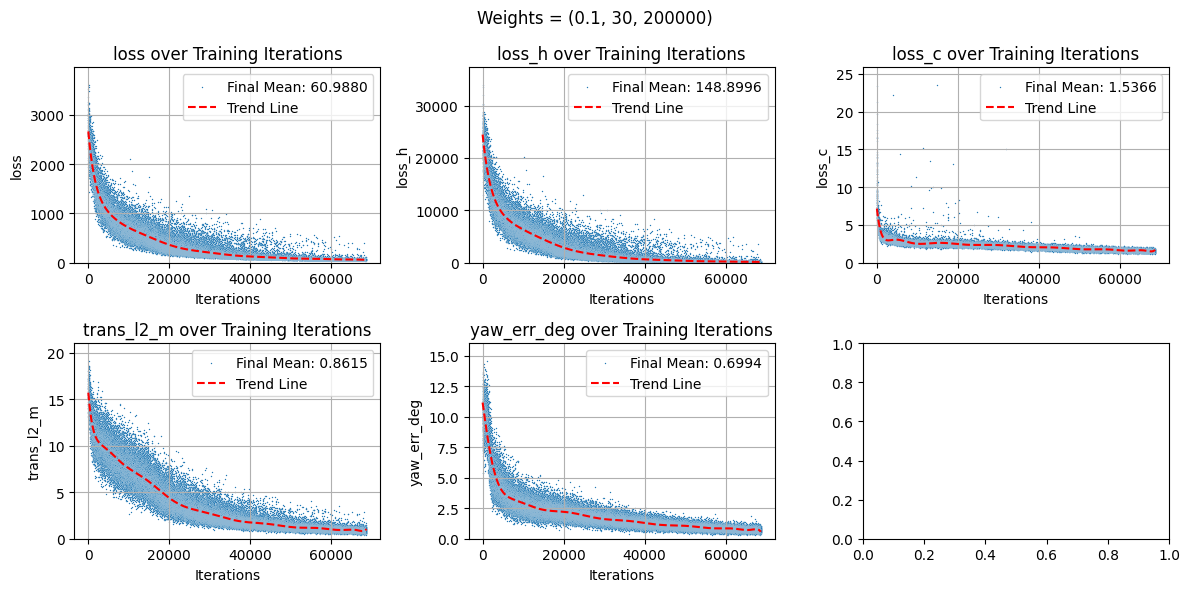

In [10]:
df = pd.read_csv("metrics/train/2026_01_09_14_36_50.csv")
plot_metric(df, "Weights = (0.1, 30, 200000)")

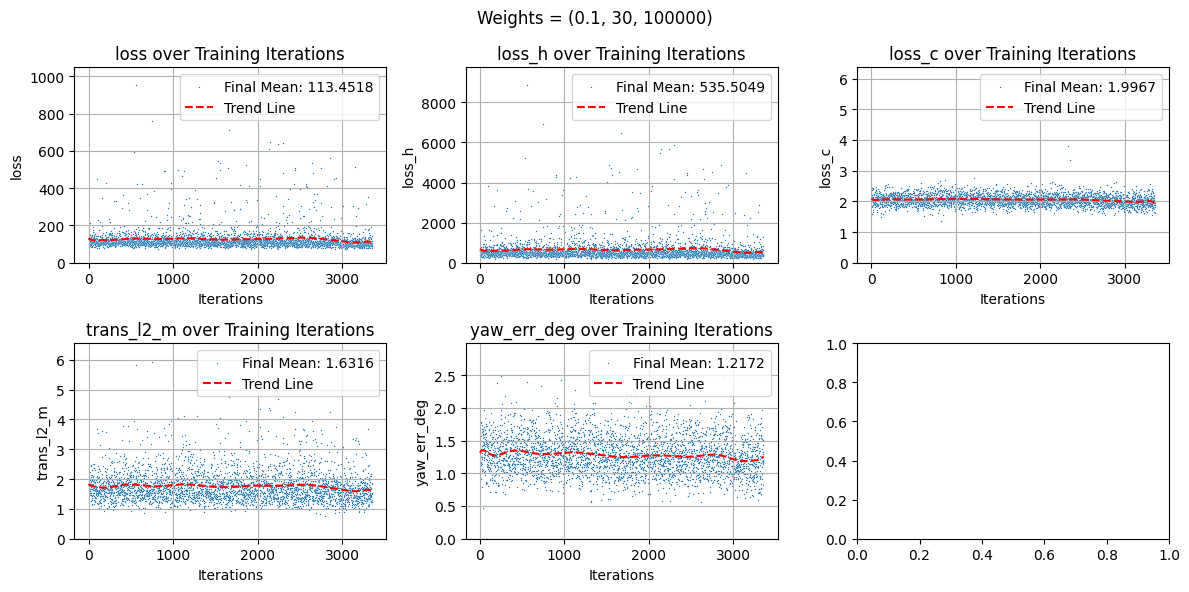

In [15]:
df = pd.read_csv("metrics/train/2026_01_11_17_52_20.csv")
plot_metric(df, "Weights = (0.1, 30, 100000)")

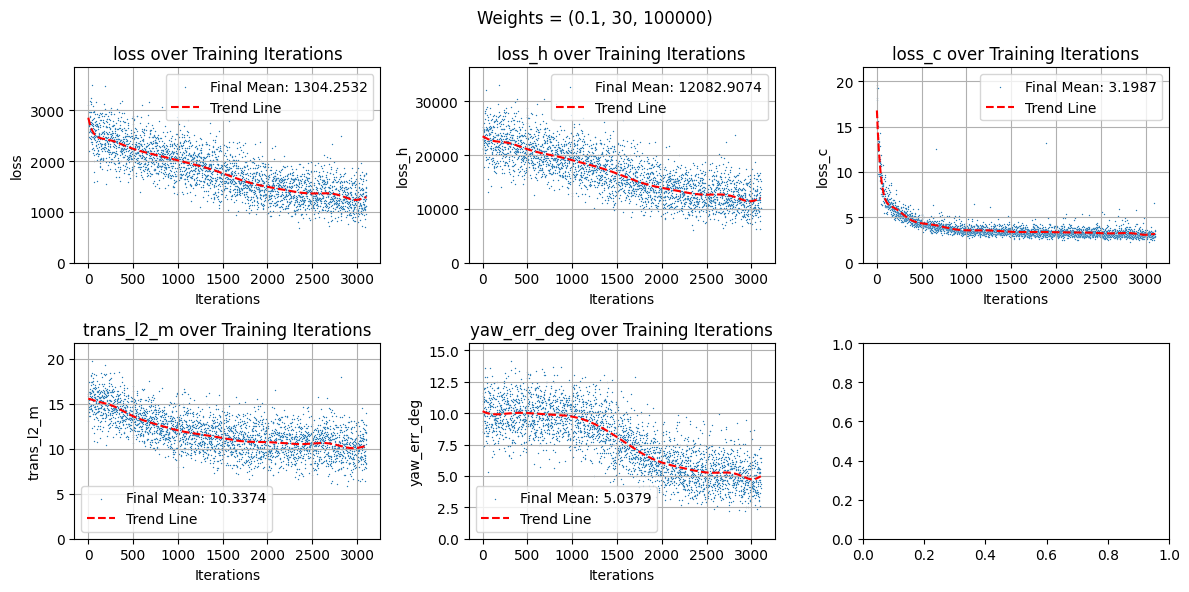

In [16]:
df = pd.read_csv("metrics/train/2026_01_11_17_36_19.csv")
plot_metric(df, "Weights = (0.1, 30, 100000)")

# Previous, faulty training

I had introduced the translation shift in the lidar points and I believe the model learned to center the points rather that leanring localization

In [16]:
fp = "metrics/train/2025_12_27_0.csv"

df = pd.read_csv(fp)

# Count how many times we've seen each (epoch, batch) so far
df["_occurrence"] = df.groupby(["epoch", "batch"]).cumcount()

# Split into two dataframes
df_model_1 = df[df["_occurrence"] == 0].drop(columns="_occurrence").reset_index(drop=True)
df_model_2 = df[df["_occurrence"] == 1].drop(columns="_occurrence").reset_index(drop=True)

print(len(df_model_1), len(df_model_2), "/", len(df))


69222 30439 / 99661


/tmp/ipykernel_3753663/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_3753663/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_3753663/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_3753663/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_3753663/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)


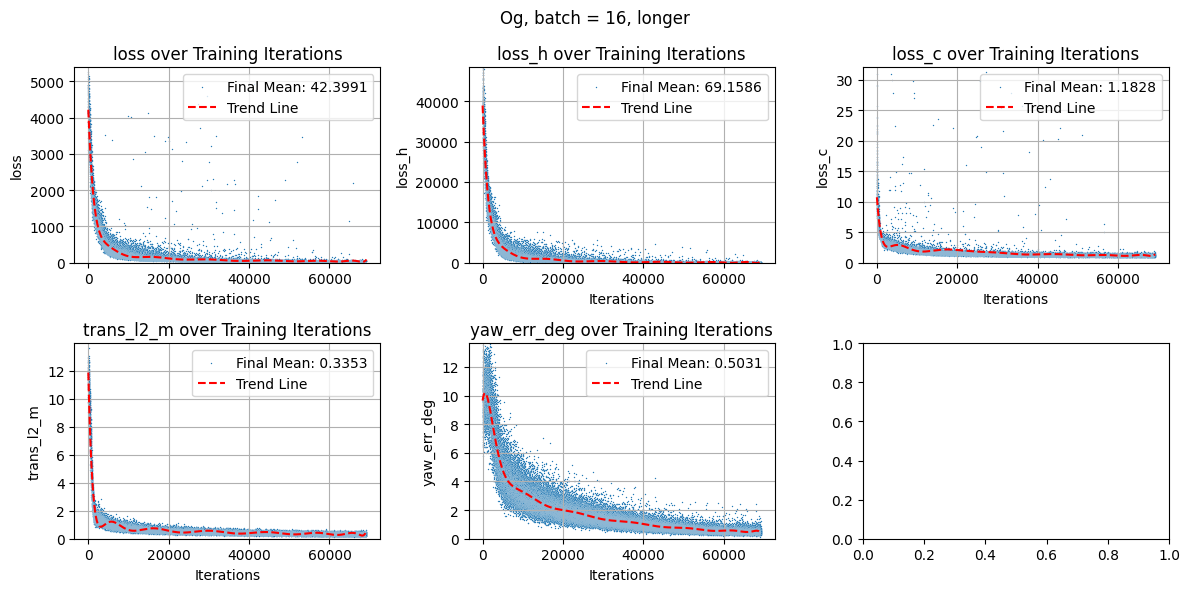

In [17]:
plot_metric(df_model_1, 'Og, batch = 16, longer')

# Validation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
fp  = "metrics/val/2026_01_03_18_13_05_hcnet_zod_eval.csv"
df = pd.read_csv(fp)


In [3]:
df.loc[df.meters_l2 > 1.5]

,scene_name,frame_name,iteration,meters_l2,yaw_err_deg,time_ms
380,1,380,11,1.5323,1.4549,18.51
985,1,986,30,1.8479,1.6117,22.62
992,17,4,31,1.5582,6.5135,22.54
1007,17,19,31,1.6560,6.9863,22.54
1223,17,235,38,1.8323,4.6673,19.79
...,...,...,...,...,...,...
7175,5,1793,224,1.6798,18.2920,23.42
7180,5,1798,224,1.6093,16.5624,23.42
8988,7,1626,280,3.8889,17.5356,21.18
8995,7,1633,281,1.5731,17.7901,25.13


In [15]:
df.iloc[ df.meters_l2.argmax()]

scene_name       2.0000
frame_name     266.0000
iteration      111.0000
meters_l2        6.5196
yaw_err_deg      0.1004
time_ms         19.0000
Name: 3577, dtype: float64

In [27]:
df.loc[ df.meters_l2 > df.meters_l2.max()*0.5]

,scene_name,frame_name,iteration,meters_l2,yaw_err_deg,time_ms
3577,2,266,111,6.5196,0.1004,19.00
3665,2,354,114,5.5123,7.8509,33.89
4106,2,795,128,4.2583,1.8210,22.04
8988,7,1626,280,3.8889,17.5356,21.18


In [16]:
df.iloc[ df.yaw_err_deg.argmax()]

scene_name        5.0000
frame_name     1399.0000
iteration       211.0000
meters_l2         0.9402
yaw_err_deg      42.1209
time_ms          21.6600
Name: 6781, dtype: float64

In [29]:
df.loc[ df.yaw_err_deg > df.yaw_err_deg.max()*0.935]

,scene_name,frame_name,iteration,meters_l2,yaw_err_deg,time_ms
5806,5,424,181,0.3185,39.6096,23.35
6781,5,1399,211,0.9402,42.1209,21.66
6783,5,1401,211,0.4822,39.6672,21.66
7700,7,338,240,0.2558,39.5674,21.44


In [34]:
df.loc[ df.meters_l2 < df.meters_l2.min()*1.5]

,scene_name,frame_name,iteration,meters_l2,yaw_err_deg,time_ms
2081,17,1093,65,0.0114,0.3671,29.93
6961,5,1579,217,0.0083,0.3570,21.99
10179,28,524,318,0.0085,4.5060,11.83


In [37]:
df.loc[ df.yaw_err_deg < df.yaw_err_deg.min()*3]

,scene_name,frame_name,iteration,meters_l2,yaw_err_deg,time_ms
1599,17,611,49,1.2158,0.0003,21.63
1711,17,723,53,0.8144,0.0007,27.01
3232,17,2244,101,0.2679,0.0008,18.97
8358,7,996,261,0.2370,0.0008,20.03


<Axes: xlabel='None', ylabel='meters_l2'>

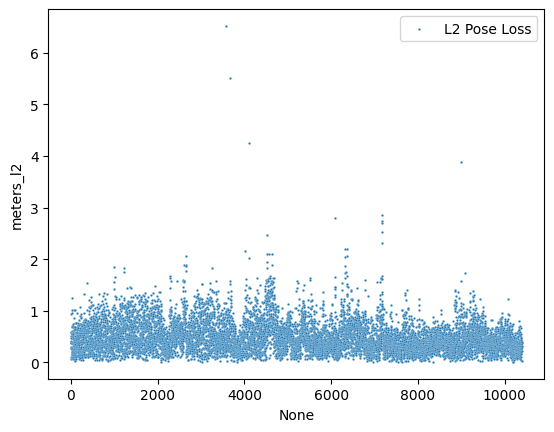

In [5]:
import seaborn as sns
sns.scatterplot(data=df, x=df.index, y='meters_l2', label='L2 Pose Loss', s=3)

<Axes: xlabel='None', ylabel='yaw_err_deg'>

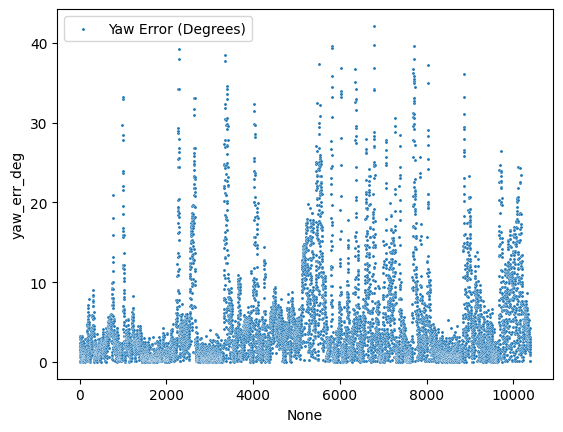

In [42]:
sns.scatterplot(data=df, x=df.index, y='yaw_err_deg', label='Yaw Error (Degrees)', s=5)

/tmp/ipykernel_2324965/4123043644.py:2: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index[700:900], df['yaw_err_deg'][700:900],20)


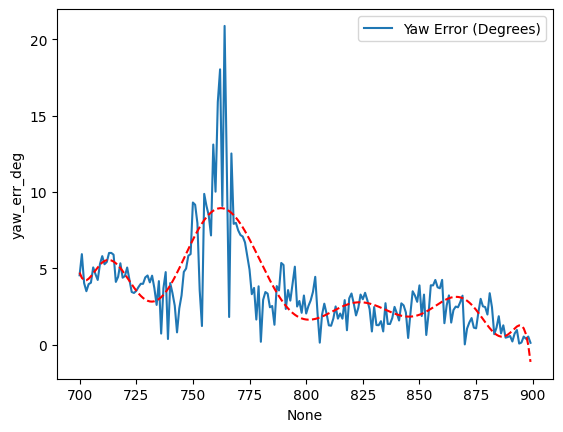

In [50]:
sns.lineplot(data=df.iloc[700:900], x=df.index[700:900], y='yaw_err_deg', label='Yaw Error (Degrees)')#, s=5)
z = np.polyfit(df.index[700:900], df['yaw_err_deg'][700:900],20)
p = np.poly1d(z)
plt.plot(df.index[700:900], p(df.index[700:900]), "r--", label='Trend Line')


{1: 0.25286250360819784, 2: 0.4331761762724911, 5: 0.7313576445684595, 10: 0.8765515250649476, 20: 0.965842393918984}


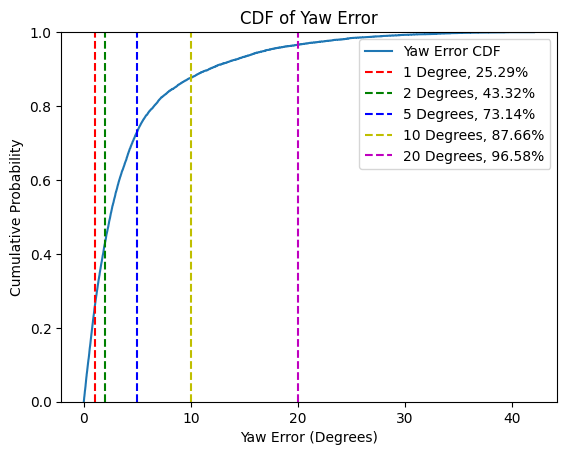

In [12]:
# compute cfd intersection points at 1,2,5,10 degrees
def compute_cdf_intersections(data, thresholds):
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    intersections = {}
    for threshold in thresholds:
        idx = np.searchsorted(sorted_data, threshold, side='right') - 1
        if idx >= 0:
            intersections[threshold] = cdf[idx]
        else:
            intersections[threshold] = 0.0
    return intersections
thresholds = [1, 2, 5, 10, 20]
intersections = compute_cdf_intersections(df['yaw_err_deg'], thresholds)
print(intersections)

# cdf plot for yaw error with 1,2, 5, 10 degree lines
sns.ecdfplot(data=df, x='yaw_err_deg', label='Yaw Error CDF')
plt.axvline(x=1, color='r', linestyle='--', label=f'1 Degree, {intersections[1]*100:.2f}%')
plt.axvline(x=2, color='g', linestyle='--', label=f'2 Degrees, {intersections[2]*100:.2f}%')
plt.axvline(x=5, color='b', linestyle='--', label=f'5 Degrees, {intersections[5]*100:.2f}%')
plt.axvline(x=10, color='y', linestyle='--', label=f'10 Degrees, {intersections[10]*100:.2f}%')
plt.axvline(x=20, color='m', linestyle='--', label=f'20 Degrees, {intersections[20]*100:.2f}%')
plt.xlabel('Yaw Error (Degrees)')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Yaw Error')
plt.legend()

{1: 0.9341864716636198, 2: 0.9979794092177428, 5: 0.9998075627826422}


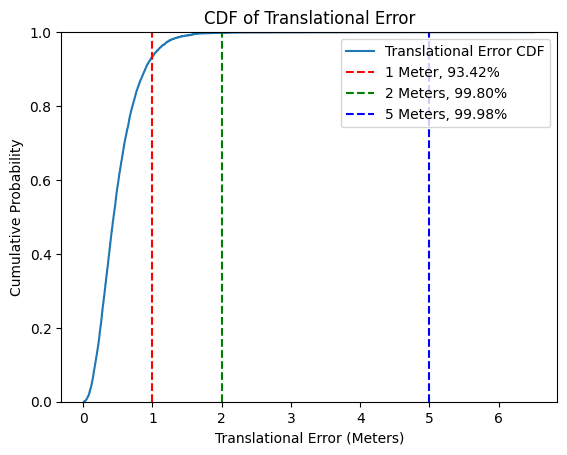

In [13]:
# compute cfd intersection points at 1,2,5,10 degrees
thresholds = [1, 2, 5]
intersections = compute_cdf_intersections(df['meters_l2'], thresholds)
print(intersections)

# cdf plot for translational error with 1,2, 5 meter lines
sns.ecdfplot(data=df, x='meters_l2', label='Translational Error CDF')
plt.axvline(x=1, color='r', linestyle='--', label=f'1 Meter, {intersections[1]*100:.2f}%')
plt.axvline(x=2, color='g', linestyle='--', label=f'2 Meters, {intersections[2]*100:.2f}%')
plt.axvline(x=5, color='b', linestyle='--', label=f'5 Meters, {intersections[5]*100:.2f}%')
plt.xlabel('Translational Error (Meters)')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Translational Error')
plt.legend()

Text(0.5, 1.0, 'Histogram of Translational Errors')

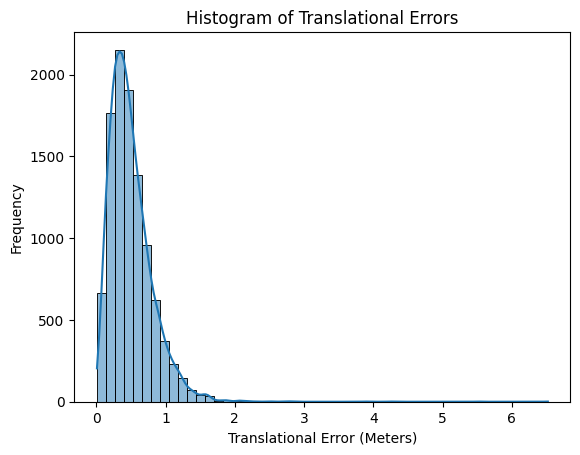

In [ ]:
# Error histogram (distribution of errors)
sns.histplot(data=df, x='meters_l2', bins=50, kde=True)
plt.xlabel('Translational Error (Meters)')
plt.ylabel('Frequency')
plt.title('Histogram of Translational Errors')

Text(0.5, 1.0, 'Histogram of Yaw Errors')

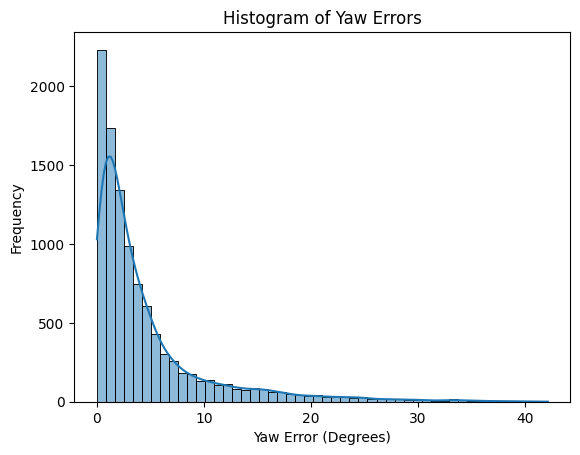

In [10]:
# Error histogram (distribution of errors)
sns.histplot(data=df, x='yaw_err_deg', bins=50, kde=True)
plt.xlabel('Yaw Error (Degrees)')
plt.ylabel('Frequency')
plt.title('Histogram of Yaw Errors')